# Unit execution for `coherence_plot.py`

This notebook is for checking and tweaking the general coherence-plotting utilities.

You can directly edit:
- the time grid,
- the exact coherence curve,
- the obtained data,
- whether you plot `abs`, `real`, `imag`, `phase`, or the full complex coherence.

The plotting utility keeps the **exact curve** and the **obtained data** in the **same color**.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from plot.coherence_plot import (
    CoherenceSeries,
    make_coherence_series_from_density_matrices,
    plot_coherence_comparison,
    plot_complex_coherence_comparison,
)

np.set_printoptions(precision=6, suppress=True)


## 1. Directly tweak a coherence curve

Edit the formulas below to test the plotting function with your own coherence model.


In [2]:
# -------- Tweakable direct coherence data --------
num_points = 80
t_max = 4.0
times = np.linspace(0.0, t_max, num_points)

# Exact coherence: edit this freely
gamma = 0.45
omega = 1.6
exact_values = 0.48 * np.exp(-gamma * times) * np.exp(1j * omega * times)

# Obtained data: edit this freely
# Here I sample every 4th point and add a controlled perturbation.
sample_step = 4
times_obt = times[::sample_step]
perturbation = 1.0 + 0.03 * np.cos(2.2 * times_obt) - 0.02j * np.sin(1.3 * times_obt)
obtained_values = exact_values[::sample_step] * perturbation

exact_series = CoherenceSeries(times=times, values=exact_values, label=r"$\rho_{01}(t)$")
obtained_series = CoherenceSeries(times=times_obt, values=obtained_values, label=r"$\rho_{01}(t)$")

print("Exact coherence shape:", exact_series.values.shape)
print("Obtained coherence shape:", obtained_series.values.shape)


Exact coherence shape: (80,)
Obtained coherence shape: (20,)


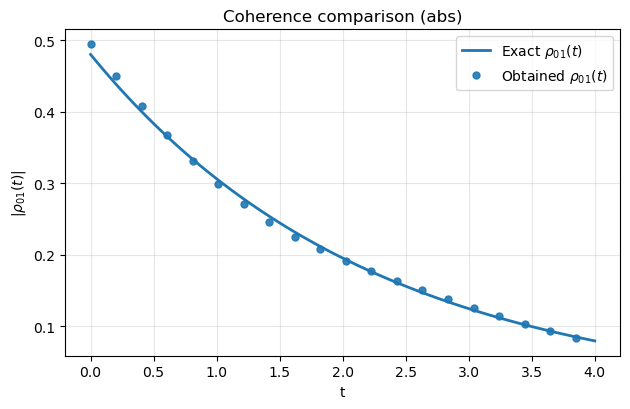

In [3]:
# Choose component from: 'abs', 'real', 'imag', 'phase'
component = "abs"

fig, ax = plot_coherence_comparison(
    exact_series,
    obtained_series,
    component=component,
    title=f"Coherence comparison ({component})",
    xlabel="t",
)
plt.show()


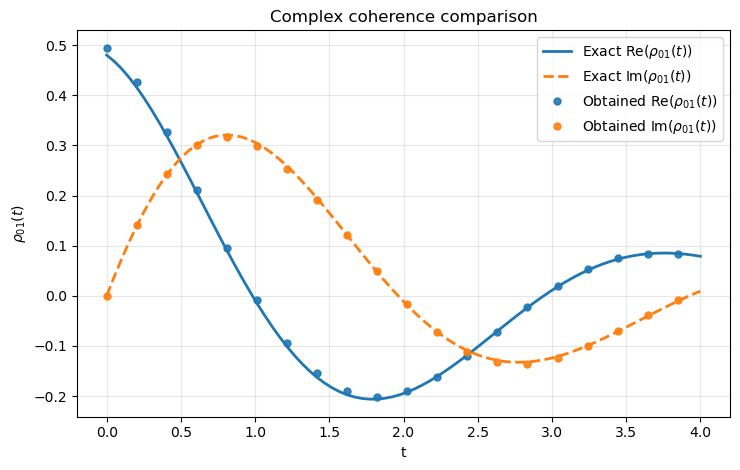

In [4]:
# Full complex coherence = two panels (real and imaginary parts)
fig, axs = plot_complex_coherence_comparison(
    exact_series,
    obtained_series,
    title="Complex coherence comparison",
    xlabel="t",
)
plt.show()


## 2. Build coherence from density matrices

This is useful for the later time-evolution notebooks, where your simulation may naturally output density matrices ρ(t).


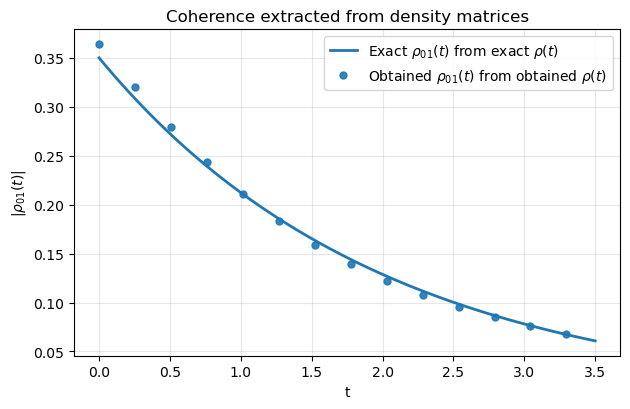

In [5]:
# -------- Tweakable density-matrix trajectory --------
times_rho = np.linspace(0.0, 3.5, 70)

# Example one-qubit trajectory:
# rho(t) = [[a(t), c(t)], [c*(t), 1-a(t)]]
a_t = 0.55 + 0.10 * np.cos(0.9 * times_rho)
c_exact = 0.35 * np.exp(-0.5 * times_rho) * np.exp(1j * 1.1 * times_rho)

rho_exact_list = []
for a, c in zip(a_t, c_exact):
    rho = np.array([[a, c], [np.conj(c), 1.0 - a]], dtype=complex)
    rho_exact_list.append(rho)

rho_exact = np.array(rho_exact_list)

# Obtained trajectory at a coarser grid
times_rho_obt = times_rho[::5]
a_t_obt = a_t[::5] + 0.01 * np.sin(2.0 * times_rho_obt)
c_obt = c_exact[::5] * (1.0 + 0.04 * np.cos(1.5 * times_rho_obt))

rho_obt_list = []
for a, c in zip(a_t_obt, c_obt):
    rho = np.array([[a, c], [np.conj(c), 1.0 - a]], dtype=complex)
    rho_obt_list.append(rho)

rho_obt = np.array(rho_obt_list)

exact_from_rho = make_coherence_series_from_density_matrices(
    times_rho,
    rho_exact,
    i=0,
    j=1,
    label=r"$\rho_{01}(t)$ from exact $\rho(t)$",
)
obtained_from_rho = make_coherence_series_from_density_matrices(
    times_rho_obt,
    rho_obt,
    i=0,
    j=1,
    label=r"$\rho_{01}(t)$ from obtained $\rho(t)$",
)

fig, ax = plot_coherence_comparison(
    exact_from_rho,
    obtained_from_rho,
    component="abs",
    title="Coherence extracted from density matrices",
)
plt.show()


## 3. Blank editable template

Replace the entries below with your own coherence values.


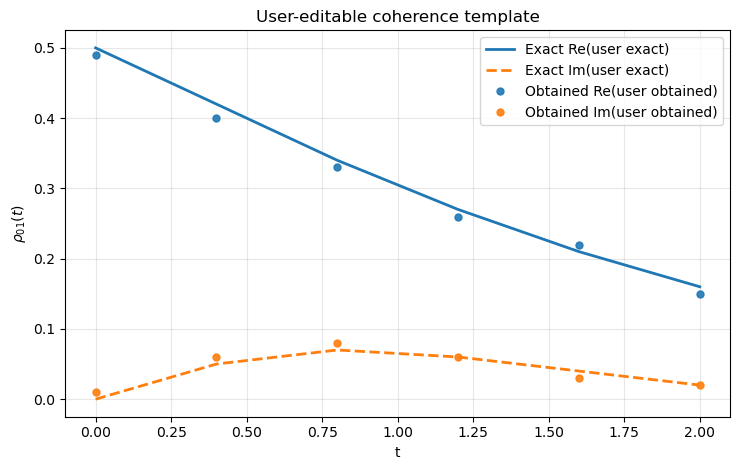

In [6]:
times_user = np.array([0.0, 0.4, 0.8, 1.2, 1.6, 2.0])
exact_user = np.array([
    0.50 + 0.00j,
    0.42 + 0.05j,
    0.34 + 0.07j,
    0.27 + 0.06j,
    0.21 + 0.04j,
    0.16 + 0.02j,
], dtype=complex)

obtained_user = np.array([
    0.49 + 0.01j,
    0.40 + 0.06j,
    0.33 + 0.08j,
    0.26 + 0.06j,
    0.22 + 0.03j,
    0.15 + 0.02j,
], dtype=complex)

series_exact_user = CoherenceSeries(times_user, exact_user, label="user exact")
series_obt_user = CoherenceSeries(times_user, obtained_user, label="user obtained")

fig, ax = plot_coherence_comparison(
    series_exact_user,
    series_obt_user,
    component="complex",   # try 'abs', 'real', 'imag', 'phase', or 'complex'
    title="User-editable coherence template",
)
plt.show()
